<Figure size 1000x600 with 0 Axes>

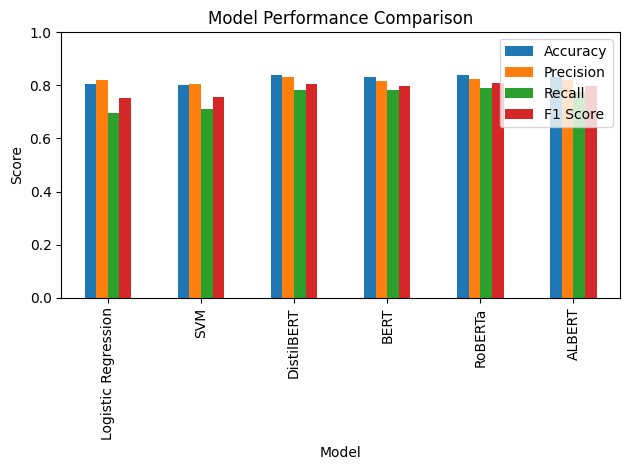

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.read_csv("model_comparison.csv")

plt.figure(figsize=(10,6))

results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar"
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)

plt.tight_layout()
plt.show()

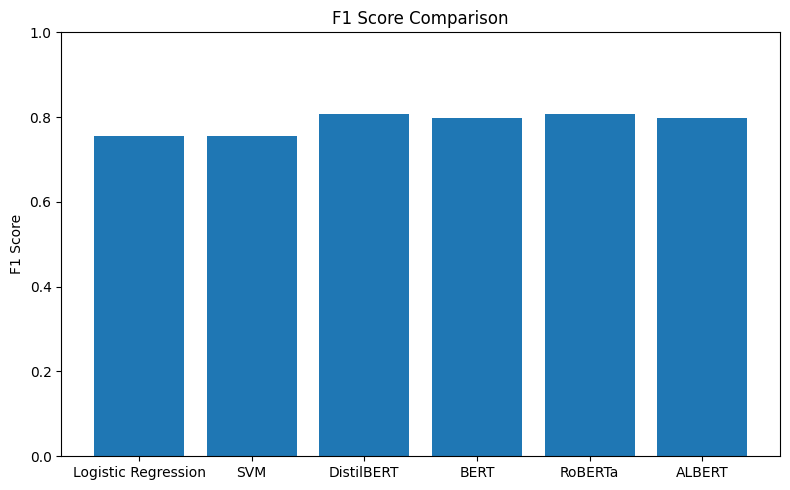

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0,1)

plt.tight_layout()
plt.show()

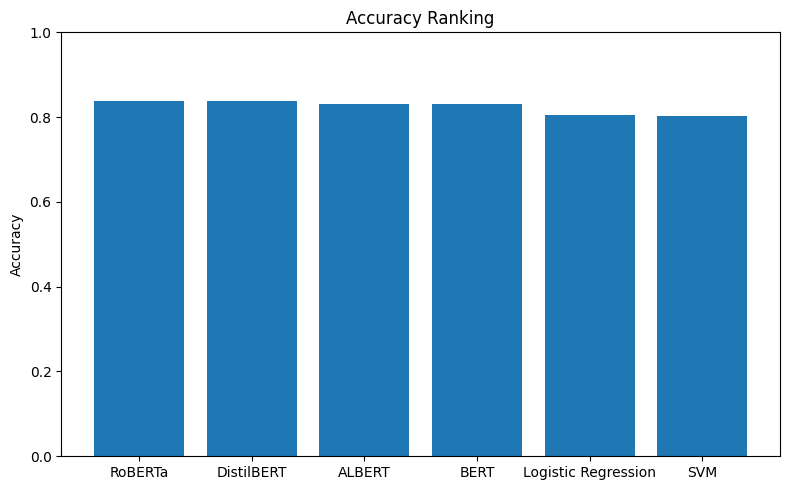

In [3]:
results_sorted = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    results_sorted["Model"],
    results_sorted["Accuracy"]
)

plt.title("Accuracy Ranking")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.tight_layout()
plt.show()

In [7]:
plt.savefig(
    "f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [8]:
plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [11]:
print(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    )
)

                 Model  Accuracy  Precision    Recall  F1 Score
4              RoBERTa  0.838477   0.825879  0.790520  0.807813
2           DistilBERT  0.838477   0.830097  0.784404  0.806604
5               ALBERT  0.831911   0.822006  0.776758  0.798742
3                 BERT  0.829941   0.814992  0.781346  0.797814
1                  SVM  0.801707   0.805556  0.709480  0.754472
0  Logistic Regression  0.804990   0.821622  0.697248  0.754342


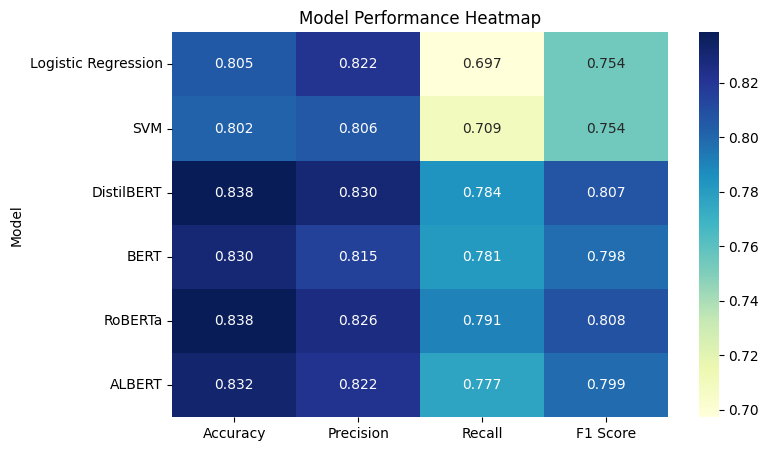

In [4]:
plt.figure(figsize=(8,5))

sns.heatmap(
    results_df.set_index("Model"),
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Model Performance Heatmap")
plt.show()

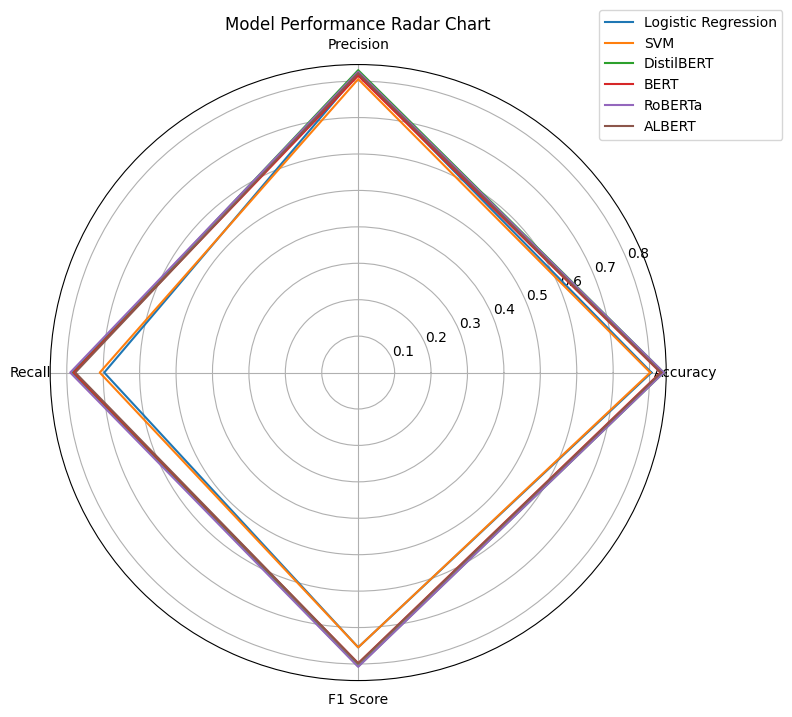

In [8]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

angles = np.linspace(
    0,
    2*np.pi,
    len(metrics),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw=dict(polar=True)
)

for _, row in results_df.iterrows():

    values = [
        row["Accuracy"],
        row["Precision"],
        row["Recall"],
        row["F1 Score"]
    ]

    values += values[:1]

    ax.plot(
        angles,
        values,
        label=row["Model"]
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

plt.legend(
    bbox_to_anchor=(1.2,1.1)
)

plt.title("Model Performance Radar Chart")
plt.show()